In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.shape

(7043, 21)

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
#target varible analyasis
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

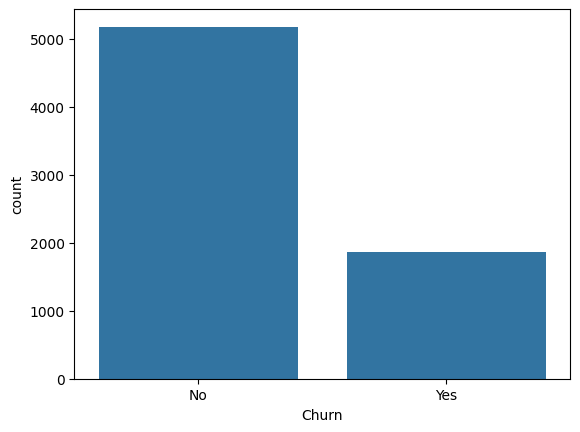

In [11]:
sns.countplot(x='Churn',data=df)
plt.show()

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
for col in df.select_dtypes(include='object').columns:
    print(col)

customerID
gender
Partner
Dependents
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
TotalCharges
Churn


In [14]:
df['TotalCharges'].dtype

dtype('O')

In [15]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [16]:
df['TotalCharges'].dtype

dtype('float64')

In [17]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [18]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

/tmp/ipykernel_16/575980950.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(


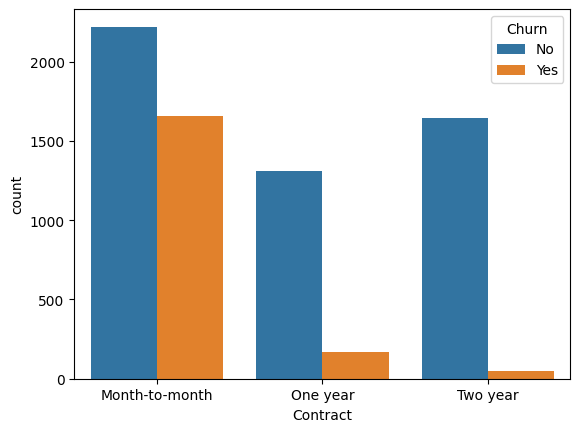

In [19]:
#churn vs Contract
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)
plt.show()

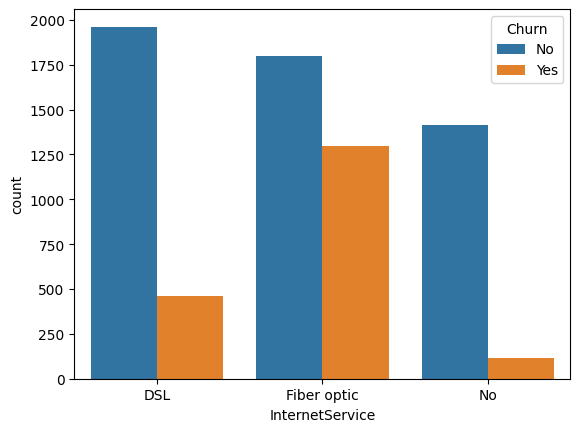

In [20]:
#churn vs Internet service
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)
plt.show()

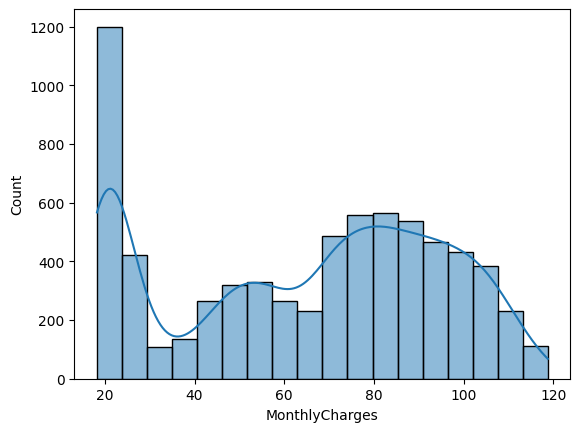

In [21]:
#monthly charges Distribution
sns.histplot(
    df['MonthlyCharges'],
    kde=True
)
plt.show()

In [22]:
df.drop(
    "customerID",
    axis=1,
    inplace=True
)

In [23]:
df['Churn'] =df['Churn'].map({
    'No':0,
    'Yes':1
})

In [24]:
df = pd.get_dummies(
    df,drop_first=True
)

In [25]:
X = df.drop("Churn",axis=1)
y = df['Churn']

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
model = LogisticRegression(max_iter=1000)

In [32]:
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [33]:
y_pred=model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score , confusion_matrix, classification_report

In [35]:
print("accuracy score is : ",accuracy_score(y_test,y_pred))

accuracy score is :  0.8197303051809794


In [36]:
from sklearn.neighbors import KNeighborsClassifier
model1 = KNeighborsClassifier(n_neighbors = 3)


In [37]:
model1.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [38]:
y_pred=model1.predict(X_test)
print("accuracy score is : ",accuracy_score(y_test,y_pred))

accuracy score is :  0.765791341376863


In [39]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier(
    criterion = 'entropy',
    splitter = 'random',
    max_depth = 3
)

In [40]:
model2.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, splitter='random')

In [41]:
y_pred=model2.predict(X_test)
print("accuracy score is : ",accuracy_score(y_test,y_pred))

accuracy score is :  0.7785663591199432


In [42]:
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier(
    n_estimators = 100,
    bootstrap = True,
    max_depth = 5,
    criterion = 'entropy'
)

In [43]:
model3.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', max_depth=5)

In [44]:
y_pred=model3.predict(X_test)
print("accuracy score is : ",accuracy_score(y_test,y_pred))

accuracy score is :  0.7984386089425124


In [45]:
from xgboost import XGBClassifier

model4 = XGBClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    random_state = 42
)

In [46]:
model4.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [47]:
y_pred=model4.predict(X_test)
print("accuracy score is : ",accuracy_score(y_test,y_pred))

accuracy score is :  0.8090844570617459


In [48]:
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

[[936 100]
 [169 204]]


In [49]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.67      0.55      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [50]:
from sklearn.model_selection import cross_val_score

In [51]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5
    )



In [52]:
    print(name)
    print("Mean:", scores.mean())
    print("Std:", scores.std())
    print()

XGBoost
Mean: 0.7810605724562875
Std: 0.00912969878110376



In [53]:
params = {

    "n_estimators":[100,200],

    "max_depth":[3,5,7],

    "learning_rate":[0.01,0.1,0.2]

}

In [54]:
from sklearn.model_selection import GridSearchCV

In [55]:
grid = GridSearchCV(

    estimator=XGBClassifier(),

    param_grid=params,

    cv=5,

    scoring="accuracy"

)

In [56]:
grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             scoring='accuracy')

In [57]:
print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [58]:
print(grid.best_score_)

0.8024499567376567


In [59]:
best_model = grid.best_estimator_

In [60]:
y_pred = best_model.predict(
    X_test
)

In [61]:
print(
    accuracy_score(
        y_test,
        y_pred
    )
)

0.8133427963094393


In [62]:
importance = pd.Series(

    best_model.feature_importances_,

    index=X.columns

)

In [63]:
importance.sort_values(
    ascending=False
)

Contract_One year                        0.210642
InternetService_Fiber optic              0.203486
Contract_Two year                        0.171877
InternetService_No                       0.083119
PaymentMethod_Electronic check           0.060990
tenure                                   0.058888
StreamingMovies_Yes                      0.037089
OnlineSecurity_Yes                       0.021039
PaperlessBilling_Yes                     0.020634
TechSupport_Yes                          0.018513
StreamingTV_Yes                          0.014841
SeniorCitizen                            0.012683
PhoneService_Yes                         0.011843
MultipleLines_Yes                        0.011517
PaymentMethod_Mailed check               0.009686
MonthlyCharges                           0.009609
TotalCharges                             0.009302
Dependents_Yes                           0.006881
PaymentMethod_Credit card (automatic)    0.006460
OnlineBackup_Yes                         0.006122


In [64]:
importance.sort_values(
    ascending=False
).head(10)

Contract_One year                 0.210642
InternetService_Fiber optic       0.203486
Contract_Two year                 0.171877
InternetService_No                0.083119
PaymentMethod_Electronic check    0.060990
tenure                            0.058888
StreamingMovies_Yes               0.037089
OnlineSecurity_Yes                0.021039
PaperlessBilling_Yes              0.020634
TechSupport_Yes                   0.018513
dtype: float32

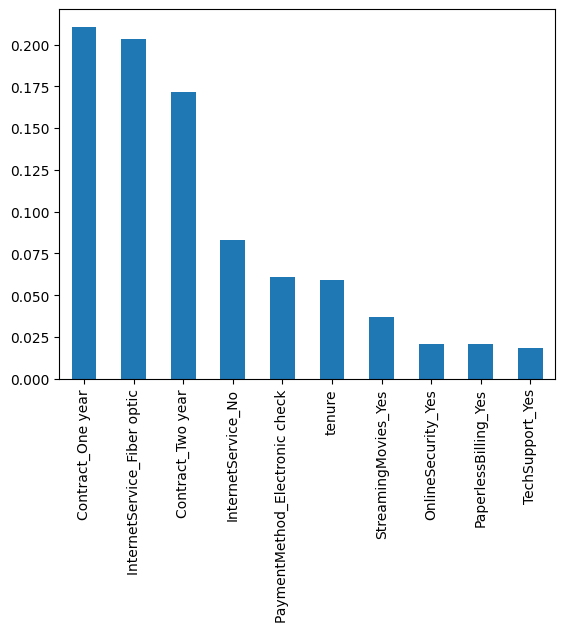

In [65]:
importance.sort_values(
    ascending=False
).head(10).plot(
    kind="bar"
)
plt.show()

In [66]:
import joblib

In [67]:
joblib.dump(
    best_model,
    "churn_model.pkl"
)

['churn_model.pkl']